In [3]:
from pathlib import Path
import json
import sqlite3

import pandas as pd
import matplotlib.pyplot as plt

from visualizations import plot_loss_history

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
DB_PATH = DATA_DIR / "training_runs.db"

conn = sqlite3.connect(DB_PATH)
conn.row_factory = sqlite3.Row

run_id = "20260405_224515_399342"

run_row = conn.execute(
    "SELECT * FROM runs WHERE run_id = ?",
    (run_id,),
).fetchone()

if run_row is None:
    raise KeyError(f"Run not found: {run_id}")

metrics_df = pd.read_sql_query(
    """
    SELECT epoch, total_loss, physics_loss, data_loss, smooth_loss, ordered_loss
    FROM metrics
    WHERE run_id = ?
    ORDER BY epoch ASC
    """,
    conn,
    params=(run_id,),
)

run_meta = dict(run_row)
hyperparams = json.loads(run_meta["hyperparams"])

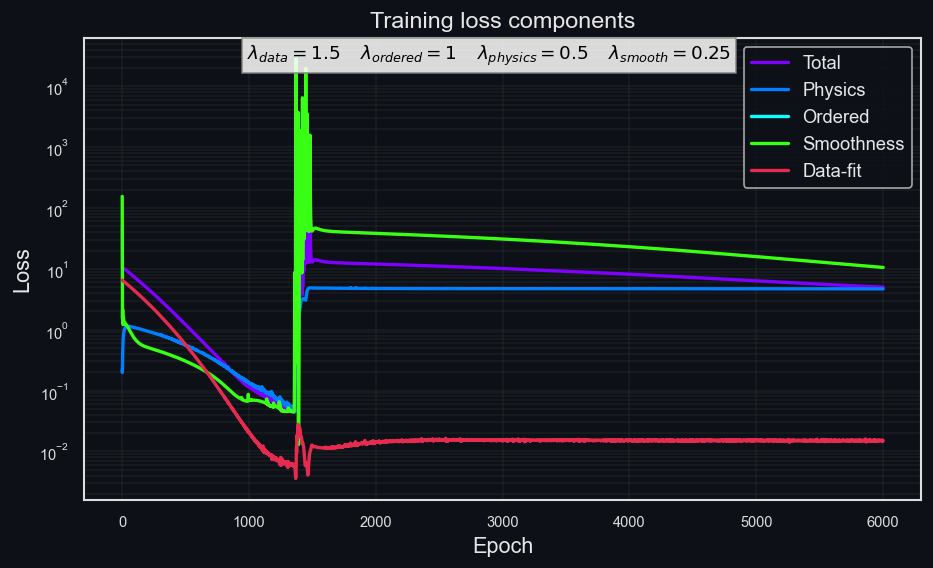

Saved plot to: C:\Users\sofia\PycharmProjects\lf-pinn-inverse-schrodinger\artifacts\demo_visuals\training_curves_20260405_224515_399342.png


In [4]:
out_path = PROJECT_ROOT / "artifacts" / "demo_visuals" / f"training_curves_{run_id}.png"

fig = plot_loss_history(
    epochs=metrics_df["epoch"],
    total=metrics_df["total_loss"],
    physics=metrics_df["physics_loss"],
    data=metrics_df["data_loss"],
    smooth=metrics_df["smooth_loss"],
    ordered=metrics_df["ordered_loss"],
    lambdas=hyperparams["lambdas"],
    out_path=out_path,
)

plt.show()
print(f"Saved plot to: {out_path.resolve()}")